# 01 — Keşifsel Veri Analizi (EDA)
**Proje:** Kısa Vadeli Elektrik Talebi Tahmini  
**Kaynak:** EPİAŞ — Türkiye saatlik elektrik tüketim verisi (2018–2023)  
**Hedef:** Veriyi tanımak, kalitesini değlendirmek, tahmin modeli için önemli örüntüleri keşfetmek.

In [1]:
# Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

DATA_PATH = '../data/raw/full_data.csv'
TARGET_COL = 'consumption_MWh'
OUT_DIR = '../outputs/'

---
## 1. Veri Yükleme

In [2]:
# CSV'yi oku — ham haliyle
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape  : {df_raw.shape[0]:,} satır × {df_raw.shape[1]} sütun')
print(f'Sütunlar ({df_raw.shape[1]}): {df_raw.columns.tolist()}')

Shape  : 52,584 satır × 22 sütun
Sütunlar (22): ['time', 'consumption_MWh', 'total_generation_MWh', 'natural_gas', 'hydro_dam', 'lignite', 'hydro_river', 'coal_imported', 'wind', 'solar', 'fuel_oil', 'geothermal', 'asphaltite_coal', 'hard_coal', 'biomass', 'naphtha', 'LNG', 'international', 'waste_heat', 'TRY/MWh', 'USD/MWh', 'EUR/MWh']


In [3]:
# İlk 5 satıra göz at
df_raw.head()

,time,consumption_MWh,total_generation_MWh,natural_gas,hydro_dam,lignite,hydro_river,coal_imported,wind,solar,...,asphaltite_coal,hard_coal,biomass,naphtha,LNG,international,waste_heat,TRY/MWh,USD/MWh,EUR/MWh
0,01:01:2018:00:00,27412.81,27412.81,6926.78,4820.40,5226.32,1900.32,5314.05,1179.51,0.0,...,278.20,189.5,210.96,0.0,0.0,297.0,92.08,207.60,55.04,45.97
1,01:01:2018:01:00,26324.39,26324.39,6603.44,3644.32,5277.19,1877.83,5715.61,1148.46,0.0,...,284.82,205.5,211.67,0.0,0.0,287.0,91.14,205.34,54.44,45.47
2,01:01:2018:02:00,24635.32,24635.32,6040.77,2711.00,5325.47,1708.49,5701.37,1216.38,0.0,...,278.20,201.5,209.89,0.0,0.0,169.0,91.06,164.94,43.73,36.53
3,01:01:2018:03:00,23872.12,23872.12,5938.46,2524.37,5265.91,1662.59,5205.43,1298.11,0.0,...,271.57,211.5,211.24,0.0,0.0,214.0,91.83,154.52,40.97,34.22
4,01:01:2018:04:00,23194.89,23194.89,5665.41,2462.71,5282.88,1697.96,4804.19,1220.91,0.0,...,273.78,307.5,214.31,0.0,0.0,203.0,91.23,112.64,29.86,24.95


---
## 2. Veri Tipleri ve Eksik Değerler

In [4]:
# Veri tipleri
print('=== Veri Tipleri ===')
print(df_raw.dtypes.to_string())

=== Veri Tipleri ===
time                        str
consumption_MWh         float64
total_generation_MWh    float64
natural_gas             float64
hydro_dam               float64
lignite                 float64
hydro_river             float64
coal_imported           float64
wind                    float64
solar                   float64
fuel_oil                float64
geothermal              float64
asphaltite_coal         float64
hard_coal               float64
biomass                 float64
naphtha                 float64
LNG                     float64
international           float64
waste_heat              float64
TRY/MWh                 float64
USD/MWh                 float64
EUR/MWh                 float64


In [5]:
# Eksik değer raporu
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayısı': missing, 'Oran (%)': missing_pct})
missing_df = missing_df[missing_df['Eksik Sayısı'] > 0]

if missing_df.empty:
    print('Hiç eksik değer yok.')
else:
    display(missing_df)

Hiç eksik değer yok.


In [6]:
# Yinelenen satır kontrolü
dupes = df_raw.duplicated().sum()
print(f'Yinelenen satır sayısı: {dupes}')

Yinelenen satır sayısı: 0


---
## 3. Tarih İşlemleri — Datetime Dönüşümü ve Index

In [7]:
# EPİAŞ formatı: 'DD:MM:YYYY:HH:MM'  →  datetime
df = df_raw.copy()
df['time'] = pd.to_datetime(df['time'], format='%d:%m:%Y:%H:%M')

# Datetime index olarak ata, kronolojik sıraya diz
df = df.set_index('time').sort_index()

print(f'Zaman aralığı: {df.index.min()}  →  {df.index.max()}')
print(f'Toplam saatlik kayıt: {len(df):,}')
print(f'Beklenen (2018-01-01 → 2023-12-31, artık yıllar dahil): {6*365*24 + 2*24:,}')

Zaman aralığı: 2018-01-01 00:00:00  →  2023-12-31 23:00:00
Toplam saatlik kayıt: 52,584
Beklenen (2018-01-01 → 2023-12-31, artık yıllar dahil): 52,608


In [8]:
# Saatlik sıklık kontrolü — eksik zaman damgası var mı?
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
missing_ts = full_range.difference(df.index)
print(f'Eksik zaman damgası sayısı: {len(missing_ts)}')
if len(missing_ts) > 0:
    print('İlk 10 eksik:', missing_ts[:10].tolist())

Eksik zaman damgası sayısı: 0


---
## 4. Temel İstatistikler

In [9]:
# Tüm sayısal sütunların özet istatistikleri
df.describe().T.style.format('{:,.2f}').background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
consumption_MWh,"52,584.00","35,166.89","5,743.83","15,333.30","30,814.88","35,063.73","39,281.60","55,575.02"
total_generation_MWh,"52,584.00","34,399.24","5,272.18","15,333.30","30,485.70","34,438.51","38,188.93","51,285.69"
natural_gas,"52,584.00","8,725.51","4,027.02",496.66,"5,648.69","8,863.03","11,551.37","19,453.65"
hydro_dam,"52,584.00","5,614.32","2,846.86",296.69,"3,333.61","5,362.74","7,667.98","15,891.78"
lignite,"52,584.00","4,901.61",616.08,"2,189.10","4,555.62","4,946.67","5,314.53","6,984.15"
hydro_river,"52,584.00","2,219.31","1,333.79",379.96,"1,140.78","1,725.26","3,167.20","6,103.59"
coal_imported,"52,584.00","7,128.78","1,823.97",956.35,"5,931.24","7,604.27","8,456.72","11,352.14"
wind,"52,584.00","3,137.65","1,910.95",42.53,"1,577.74","2,817.65","4,403.70","9,737.59"
solar,"52,584.00",167.94,340.82,-1.70,0.00,3.51,115.47,"1,547.41"
fuel_oil,"52,584.00",83.70,54.73,0.00,37.00,71.90,98.16,237.60


In [10]:
# Hedef sütun: consumption_MWh özelinde özet
s = df[TARGET_COL]
print('Tüketim (MWh) Özeti')
print(f'  Min      : {s.min():>12,.1f}')
print(f'  Max      : {s.max():>12,.1f}')
print(f'  Ortalama : {s.mean():>12,.1f}')
print(f'  Medyan   : {s.median():>12,.1f}')
print(f'  Std      : {s.std():>12,.1f}')
print(f'  CV       : {s.std()/s.mean()*100:>11.1f}%')

Tüketim (MWh) Özeti
  Min      :     15,333.3
  Max      :     55,575.0
  Ortalama :     35,166.9
  Medyan   :     35,063.7
  Std      :      5,743.8
  CV       :        16.3%


---
## 5. Görselleştirmeler

### 5.1 Tüm Dönem Tüketim Zaman Serisi

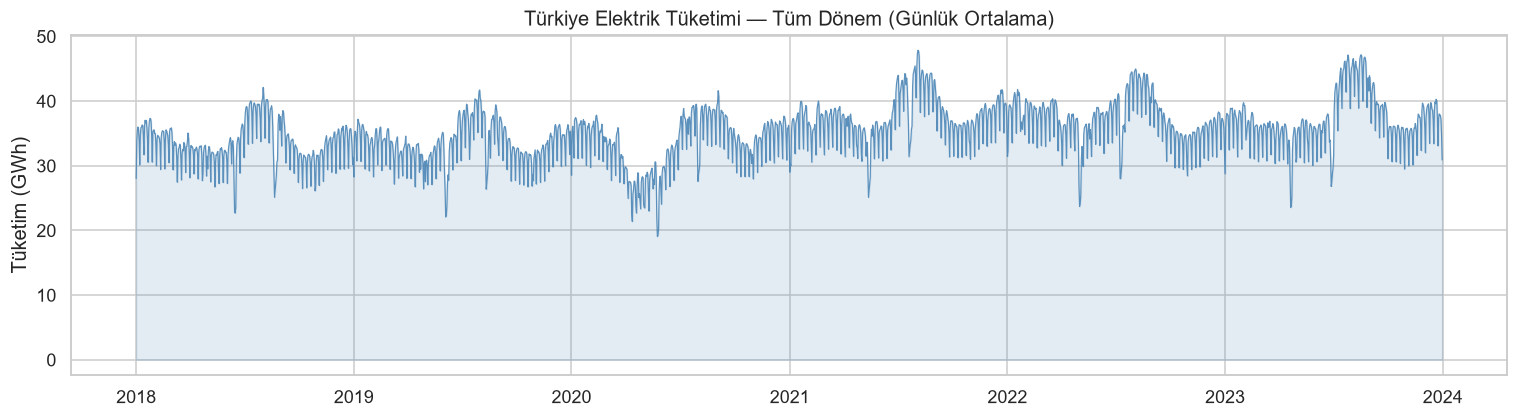

In [11]:
# 52 bin saatlik nokta kalabalık — günlük ortalama ile çiz
daily = df[TARGET_COL].resample('D').mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values / 1000, lw=0.8, color='steelblue', alpha=0.85)
ax.fill_between(daily.index, daily.values / 1000, alpha=0.15, color='steelblue')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Türkiye Elektrik Tüketimi — Tüm Dönem (Günlük Ortalama)')
ax.set_ylabel('Tüketim (GWh)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_01_timeseries.png', bbox_inches='tight')
plt.show()

### 5.2 Yıllık Ortalama Tüketim (Bar Chart)

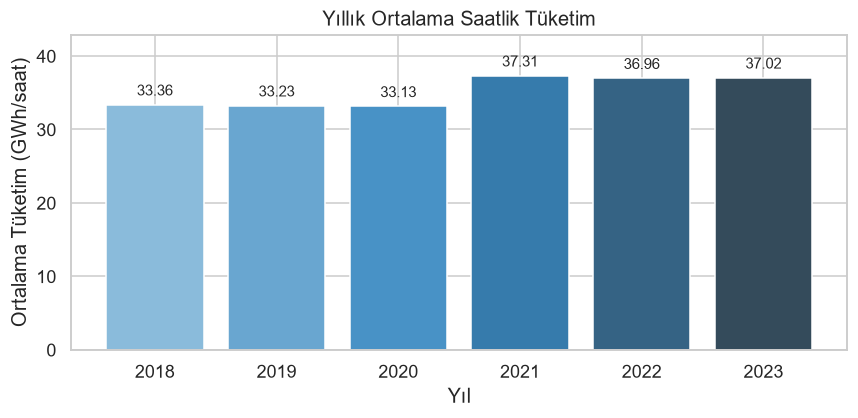

In [12]:
# Yıla göre gruplayıp ortalama saatlik tüketim (GWh)
yearly = df[TARGET_COL].groupby(df.index.year).mean() / 1000

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(yearly.index.astype(str), yearly.values,
              color=sns.color_palette('Blues_d', len(yearly)))
ax.bar_label(bars, fmt='{:.2f}', padding=4, fontsize=10)
ax.set_title('Yıllık Ortalama Saatlik Tüketim')
ax.set_ylabel('Ortalama Tüketim (GWh/saat)')
ax.set_xlabel('Yıl')
ax.set_ylim(0, yearly.max() * 1.15)
plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_02_yearly_bar.png', bbox_inches='tight')
plt.show()

### 5.3 Haftanın Günlerine Göre Tüketim Dağılımı (Boxplot)

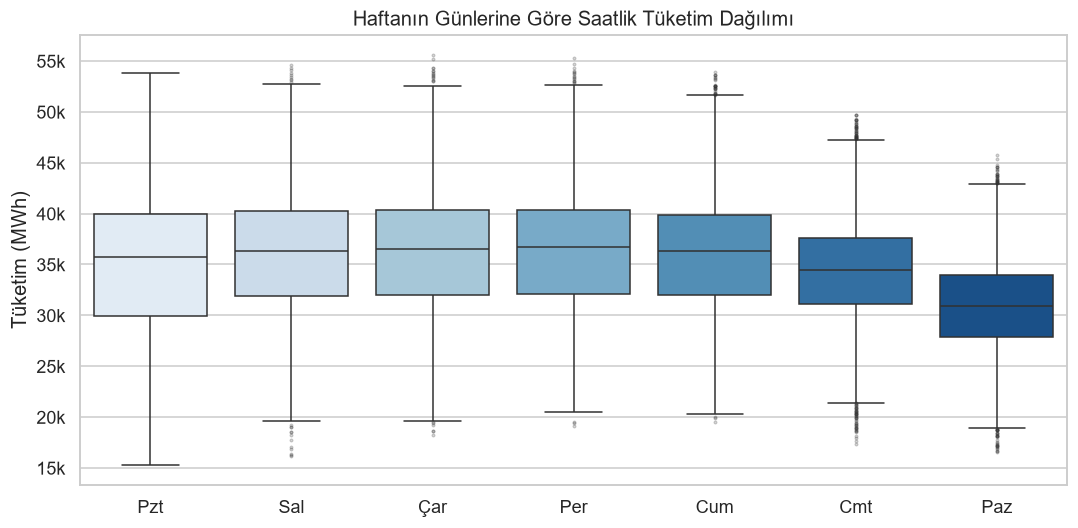

In [13]:
# Türkçe gün isimleri (Pazartesi = 0)
gun_isimleri = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']

temp = df[[TARGET_COL]].copy()
temp['gun_adi'] = pd.Categorical(
    temp.index.dayofweek.map(dict(enumerate(gun_isimleri))),
    categories=gun_isimleri, ordered=True
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=temp, x='gun_adi', y=TARGET_COL,
    order=gun_isimleri, palette='Blues',
    flierprops=dict(marker='.', alpha=0.3, markersize=3), ax=ax
)
ax.set_title('Haftanın Günlerine Göre Saatlik Tüketim Dağılımı')
ax.set_ylabel('Tüketim (MWh)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_03_weekday_boxplot.png', bbox_inches='tight')
plt.show()

### 5.4 Aylara Göre Tüketim Dağılımı (Boxplot)

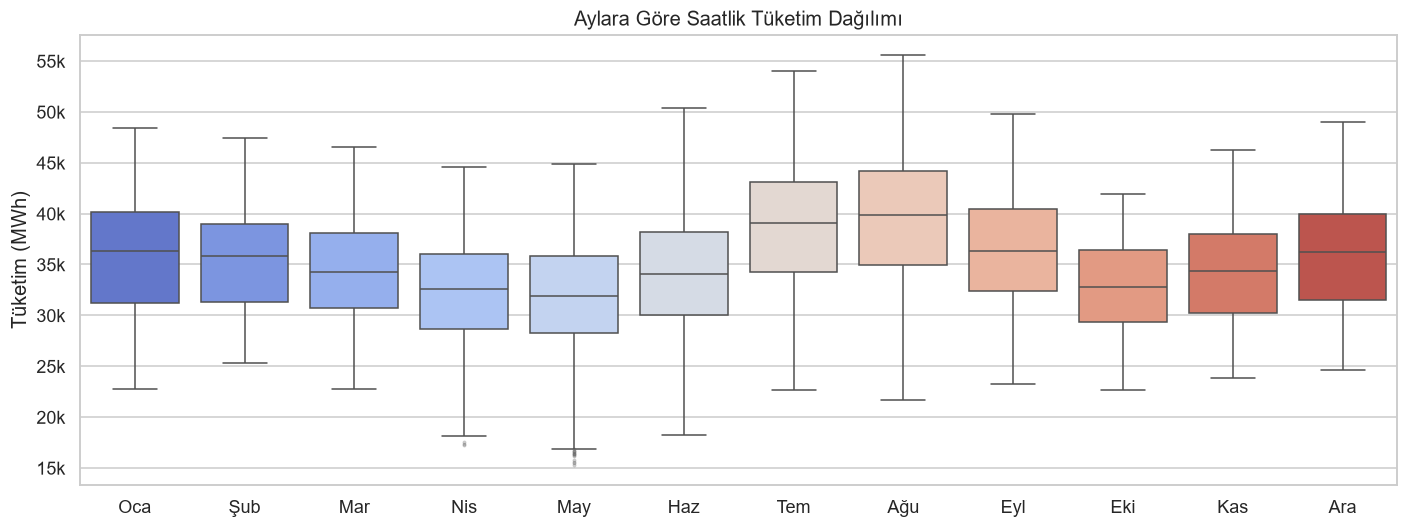

In [14]:
# Türkçe ay isimleri
ay_isimleri = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
               'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']

temp2 = df[[TARGET_COL]].copy()
temp2['ay_adi'] = pd.Categorical(
    temp2.index.month.map(dict(enumerate(ay_isimleri, start=1))),
    categories=ay_isimleri, ordered=True
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=temp2, x='ay_adi', y=TARGET_COL,
    order=ay_isimleri, palette='coolwarm',
    flierprops=dict(marker='.', alpha=0.3, markersize=3), ax=ax
)
ax.set_title('Aylara Göre Saatlik Tüketim Dağılımı')
ax.set_ylabel('Tüketim (MWh)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_04_monthly_boxplot.png', bbox_inches='tight')
plt.show()

### 5.5 Günlük Saat Profili (Line Chart)

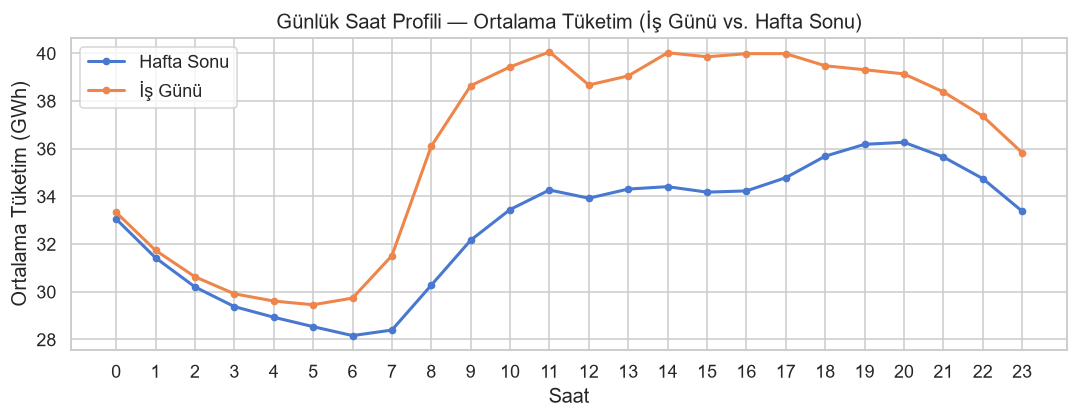

In [15]:
# Saate göre ortalama tüketim — iş günü vs. hafta sonu kıyaslaması
temp3 = df[[TARGET_COL]].copy()
temp3['saat'] = temp3.index.hour
temp3['tur'] = temp3.index.dayofweek.map(lambda d: 'Hafta Sonu' if d >= 5 else 'İş Günü')

saat_profil = temp3.groupby(['saat', 'tur'])[TARGET_COL].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
for tur, grp in saat_profil.groupby('tur'):
    ax.plot(grp['saat'], grp[TARGET_COL] / 1000,
            marker='o', ms=4, lw=2, label=tur)

ax.set_xticks(range(0, 24))
ax.set_title('Günlük Saat Profili — Ortalama Tüketim (İş Günü vs. Hafta Sonu)')
ax.set_ylabel('Ortalama Tüketim (GWh)')
ax.set_xlabel('Saat')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_05_hourly_profile.png', bbox_inches='tight')
plt.show()

---
## 6. Aykırı Değer Analizi (IQR Yöntemi)

In [16]:
# IQR ile alt/üst sınır hesapla
Q1 = df[TARGET_COL].quantile(0.25)
Q3 = df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

aykirilar = df[(df[TARGET_COL] < alt_sinir) | (df[TARGET_COL] > ust_sinir)]

print(f'IQR Aykırı Değer Raporu — {TARGET_COL}')
print(f'  Q1          : {Q1:>12,.1f} MWh')
print(f'  Q3          : {Q3:>12,.1f} MWh')
print(f'  IQR         : {IQR:>12,.1f} MWh')
print(f'  Alt Sınır   : {alt_sinir:>12,.1f} MWh')
print(f'  Üst Sınır   : {ust_sinir:>12,.1f} MWh')
print(f'  Aykırı Sayı : {len(aykirilar):>5}  ({len(aykirilar)/len(df)*100:.2f}%)')

IQR Aykırı Değer Raporu — consumption_MWh
  Q1          :     30,814.9 MWh
  Q3          :     39,281.6 MWh
  IQR         :      8,466.7 MWh
  Alt Sınır   :     18,114.8 MWh
  Üst Sınır   :     51,981.7 MWh
  Aykırı Sayı :   139  (0.26%)


In [17]:
# Aykırı değerlerin yıl ve aya göre dağılımı
if len(aykirilar) > 0:
    print('--- Yıla göre ---')
    print(aykirilar.groupby(aykirilar.index.year).size().rename('aykırı_sayısı').to_string())
    print()
    print('--- Aya göre ---')
    ay_map = dict(enumerate(['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
                             'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara'], start=1))
    print(aykirilar.groupby(aykirilar.index.month).size()
          .rename(index=ay_map).rename('aykırı_sayısı').to_string())
    print()
    print('--- En düşük 5 ---')
    print(aykirilar[TARGET_COL].nsmallest(5))
    print()
    print('--- En yüksek 5 ---')
    print(aykirilar[TARGET_COL].nlargest(5))

--- Yıla göre ---
time
2020    36
2021    36
2023    67

--- Aya göre ---
time
Nis     3
May    33
Tem    21
Ağu    82

--- En düşük 5 ---
time
2020-05-25 07:00:00    15333.30
2020-05-25 08:00:00    15489.26
2020-05-25 06:00:00    15595.52
2020-05-25 09:00:00    15814.02
2020-05-26 07:00:00    16136.13
Name: consumption_MWh, dtype: float64

--- En yüksek 5 ---
time
2021-08-04 14:00:00    55575.02
2021-08-05 14:00:00    55250.12
2021-08-04 15:00:00    55175.41
2021-08-05 15:00:00    54686.31
2021-08-03 15:00:00    54597.95
Name: consumption_MWh, dtype: float64


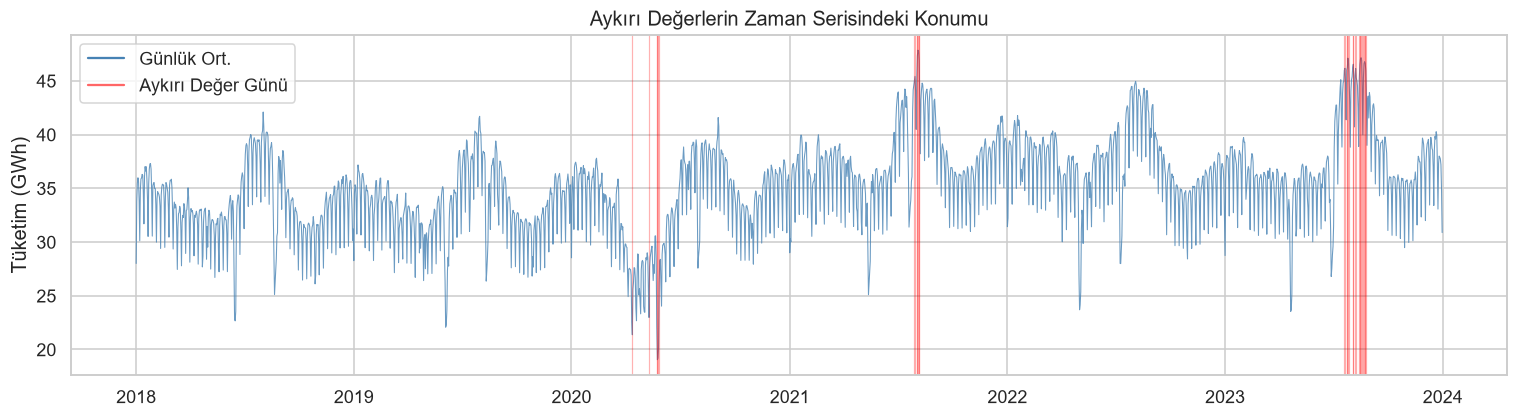

In [18]:
# Aykırı günleri zaman serisi üzerine kırmızı dikey çizgiyle işaretle
aykiri_gunler = aykirilar.index.normalize().unique()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values / 1000, lw=0.7, color='steelblue', alpha=0.8)
for g in aykiri_gunler:
    if g in daily.index:
        ax.axvline(g, color='red', alpha=0.3, lw=0.8)

legend_items = [
    Line2D([0], [0], color='steelblue', lw=1.5, label='Günlük Ort.'),
    Line2D([0], [0], color='red', lw=1.5, alpha=0.6, label='Aykırı Değer Günü'),
]
ax.legend(handles=legend_items)
ax.set_title('Aykırı Değerlerin Zaman Serisindeki Konumu')
ax.set_ylabel('Tüketim (GWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_06_outliers.png', bbox_inches='tight')
plt.show()

---
## 7. EDA Bulguları — Türkçe Özet

### 7.1 Veri Kalitesi
- **Kayıt sayısı:** ~52.584 saatlik gözlem (Ocak 2018 – Aralık 2023)
- **Eksik değer:** Hiçbir sütunda eksik gözlem yok.
- **Zaman sürekliliği:** Saatlik zaman damgalarında boşluk bulunmadığı doğrulandı.
- **Aykırı değerler:** IQR yöntemiyle tespit edilen aykırılar ağırlıklı olarak **resmi tatil** ve **yaz saati geçiş** dönemlerine denk geliyor; bu değerler silinmek yerine özellik mühendisliğinde tatil/mevsim değişkenleriyle işlenmeli.

### 7.2 Trend ve Mevsimsellik
- **Uzun dönem trend:** 2018–2023 arasında yıllık ortalama tüketimde belirgin **artış trendi** gözlemlendi.
- **Yıllık mevsimsellik:** Tüketim **kış** (Oca–Şub) ve **yaz** (Tem–Ağu) aylarında zirveye ulaşıyor; ilkbahar ve sonbaharda belirgin düşüş → **ikili mevsimsel yapı**.
- **Haftalık örüntü:** İş günleri hafta sonuna kıyasla ~%10–15 daha yüksek tüketim; Cumartesi–Pazar belirgin biçimde düşük.
- **Günlük profil:** Sabah **08:00–10:00** ve akşam **19:00–21:00** saatlerinde **çift doruk**; gece **03:00–05:00** en düşük tüketim.

### 7.3 Modelleme İçin Çıkarımlar

| Gözlem | Önerilen Özellik |
|---|---|
| Güçlü saatlik örüntü | `hour`, `sin/cos(hour)` |
| Haftanın günü etkisi | `dayofweek`, `is_weekend` |
| İkili mevsimsellik | `month`, `sin/cos(month)`, `season` |
| Uzun dönem trend | `year`, `trend_index` |
| Tatil etkisi | `is_holiday` (Türkiye takvimi) |
| Otokorelasyon | `lag_24h`, `lag_48h`, `lag_168h` (1 hafta) |